In [1]:
import xarray as xr
import pandas as pd
import numpy as np

import pygmt
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle,Polygon
import ultraplot as plot

import cartopy.crs as ccrs

import os

/opt/conda/envs/texas-env/lib/python3.10/site-packages/proplot/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


In [2]:
from pathlib import Path
from cmdstanpy import set_cmdstan_path, cmdstan_path

preferred = Path("/opt/cmdstan/cmdstan-2.36.0")
if (preferred / "bin" / "stanc").exists():
    set_cmdstan_path(str(preferred))
    print("Set CMDSTAN ->", cmdstan_path())
else:
    print("Preferred CmdStan not found:", preferred)
    print("Using:", cmdstan_path())


from TEXAS.utils.paths import PROJECT_ROOT, PACKAGE_ROOT, STAN_MODELS_DIR, CMDSTAN_DIR, ONEDRIVE
print(PROJECT_ROOT, PACKAGE_ROOT, STAN_MODELS_DIR, CMDSTAN_DIR, ONEDRIVE)

from cmdstanpy import cmdstan_path
from pathlib import Path


print("CmdStan in use:", cmdstan_path())
print("OneDrive mount exists? ", Path("/mnt/onedrive").exists())


local_github_path = str(PROJECT_ROOT)  # shim for old code
local_onedrive_path = str(ONEDRIVE)

Set CMDSTAN -> /opt/cmdstan/cmdstan-2.36.0
/home/micromamba/app /home/micromamba/app/src/TEXAS /home/micromamba/app/src/TEXAS/stan_models /opt/cmdstan/cmdstan-2.36.0 /mnt/onedrive
CmdStan in use: /opt/cmdstan/cmdstan-2.36.0
OneDrive mount exists?  True


In [3]:
# Gridded coretop
fpath = f'{local_github_path}/data/external/ncfiles/'
fname = 'ds06_calculated_ocean_properties.nc'

ocean_properties_ds = xr.open_dataset(os.path.join(fpath, fname))

fpath = f'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature/'
fname = 'woa23_decav91C0_t00_04.nc'
woa23_decav91C0_t00_04 = xr.open_dataset(os.path.join(fpath, fname),decode_times=False)
SST = woa23_decav91C0_t00_04['t_an'].sel(depth=0).rename('sst')
ocean_properties_ds['sst'] = SST.drop_vars('depth')
display(ocean_properties_ds)

fpath = f'{local_github_path}/data/external/ncfiles/'
fname = 'ds_gridded_coretop_tex_scaledRI_revised_081525.nc'
coretop_ds = xr.open_dataset(os.path.join(fpath, fname))
coretop_ds
coretop_ds_merged = xr.merge([coretop_ds, ocean_properties_ds])



coretop_df = coretop_ds_merged.to_dataframe()
coretop_df = coretop_df[coretop_df['gdgt23ratio_median']<100].reset_index()  # remove outliers
coretop_df

<xarray.Dataset>
Dimensions:        (lat: 720, lon: 1440, time: 1)
Coordinates:
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
  * time           (time) float32 1.878e+03
Data variables:
    no3_sf2tc_avg  (lat, lon) float32 ...
    no3_tc         (lat, lon) float32 ...
    t_sf2tc_avg    (lat, lon) float32 ...
    tc_depth       (lat, lon) float32 ...
    t_tc           (lat, lon) float32 ...
    sst            (time, lat, lon) float32 ...
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

,lat,lon,time,region_ID,tex_count,tex_median,tex_mean,tex_std,scaledRI_count,scaledRI_median,...,gdgt23ratio_mean,gdgt23ratio_std,modernWaterDepth_mean,mahalanobis_distance_mean,no3_sf2tc_avg,no3_tc,t_sf2tc_avg,tc_depth,t_tc,sst
0,-77.875,-40.375,1878.0,46.0,1.0,0.413650,0.413650,NaN,1.0,0.509982,...,1.502839,NaN,928.0,2.684224,NaN,NaN,-1.636017,30.0,-1.75611,-1.64841
1,-77.375,-158.375,1878.0,32.0,1.0,0.351000,0.351000,NaN,1.0,0.438075,...,2.833333,NaN,1081.0,2.016756,NaN,NaN,-1.586854,50.0,-1.66971,-1.50741
2,-77.125,-45.375,1878.0,46.0,1.0,0.367016,0.367016,NaN,1.0,0.410931,...,1.824832,NaN,332.0,2.380477,NaN,NaN,-1.692642,30.0,-1.76631,-1.70171
3,-76.625,-35.375,1878.0,46.0,1.0,0.335974,0.335974,NaN,1.0,0.433342,...,2.066396,NaN,932.0,2.422640,28.365620,28.426125,-1.498910,10.0,-1.56971,-1.42831
4,-76.375,-33.875,1878.0,46.0,1.0,0.342342,0.342342,NaN,1.0,0.447518,...,2.040640,NaN,839.0,2.392552,29.118933,29.757280,-1.651191,40.0,-1.75551,-1.74881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1348,84.875,40.625,1878.0,3.0,1.0,0.334000,0.334000,NaN,1.0,0.459150,...,4.516129,NaN,4018.0,2.447200,7.665815,9.033155,-1.373924,125.0,0.08159,-1.64041
1349,86.625,152.125,1878.0,3.0,1.0,0.490000,0.490000,NaN,1.0,0.382600,...,21.272727,NaN,1467.0,3.324040,7.059811,9.083502,-1.156047,175.0,0.24909,-1.57041
1350,86.875,-146.125,1878.0,3.0,1.0,0.438000,0.438000,NaN,1.0,0.399850,...,9.555556,NaN,3368.0,4.652252,8.384475,9.424562,-1.477433,150.0,-0.88321,-1.57180
1351,87.125,104.625,1878.0,3.0,1.0,0.500000,0.500000,NaN,1.0,0.433075,...,2.870370,NaN,4443.0,3.303009,6.828367,8.589128,-1.377392,150.0,-0.05211,-1.73371


In [4]:
def create_latlon_boundary(lon_min, lon_max, lat_min, lat_max, n_points=50):
    """
    Create a polygon that follows lat/lon grid lines for proper display 
    on different map projections.
    
    Parameters:
    -----------
    lon_min, lon_max : float
        Longitude bounds
    lat_min, lat_max : float  
        Latitude bounds
    n_points : int
        Number of points along each edge (more points = smoother curves)
    
    Returns:
    --------
    boundary_lons, boundary_lats : arrays
        Arrays of longitude and latitude points defining the boundary
    """
    
    # Create the four edges of the bounding box with many points
    
    # Bottom edge (lat_min, varying lon)
    bottom_lons = np.linspace(lon_min, lon_max, n_points)
    bottom_lats = np.full(n_points, lat_min)
    
    # Right edge (lon_max, varying lat)  
    right_lons = np.full(n_points, lon_max)
    right_lats = np.linspace(lat_min, lat_max, n_points)
    
    # Top edge (lat_max, varying lon) - reverse order to close polygon
    top_lons = np.linspace(lon_max, lon_min, n_points)
    top_lats = np.full(n_points, lat_max)
    
    # Left edge (lon_min, varying lat) - reverse order to close polygon
    left_lons = np.full(n_points, lon_min)  
    left_lats = np.linspace(lat_max, lat_min, n_points)
    
    # Concatenate all edges
    boundary_lons = np.concatenate([bottom_lons, right_lons, top_lons, left_lons])
    boundary_lats = np.concatenate([bottom_lats, right_lats, top_lats, left_lats])
    
    return boundary_lons, boundary_lats

/opt/conda/envs/texas-env/lib/python3.10/site-packages/matplotlib_inline/backend_inline.py:27: ProplotWarning: Got conflicting or duplicate keyword args: {'figwidth': 13.33, 'width': 12}. Using the first one.
  return new_figure_manager_given_figure(num, FigureClass(*args, **kwargs))
/opt/conda/envs/texas-env/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/opt/conda/envs/texas-env/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/opt/conda/envs/texas-env/lib/python3.10/site-packages/proplot/figure.py:469: MatplotlibDeprecationWarning: print_figure() got unexpected keyword argument "box_inches" which is no longer supporte

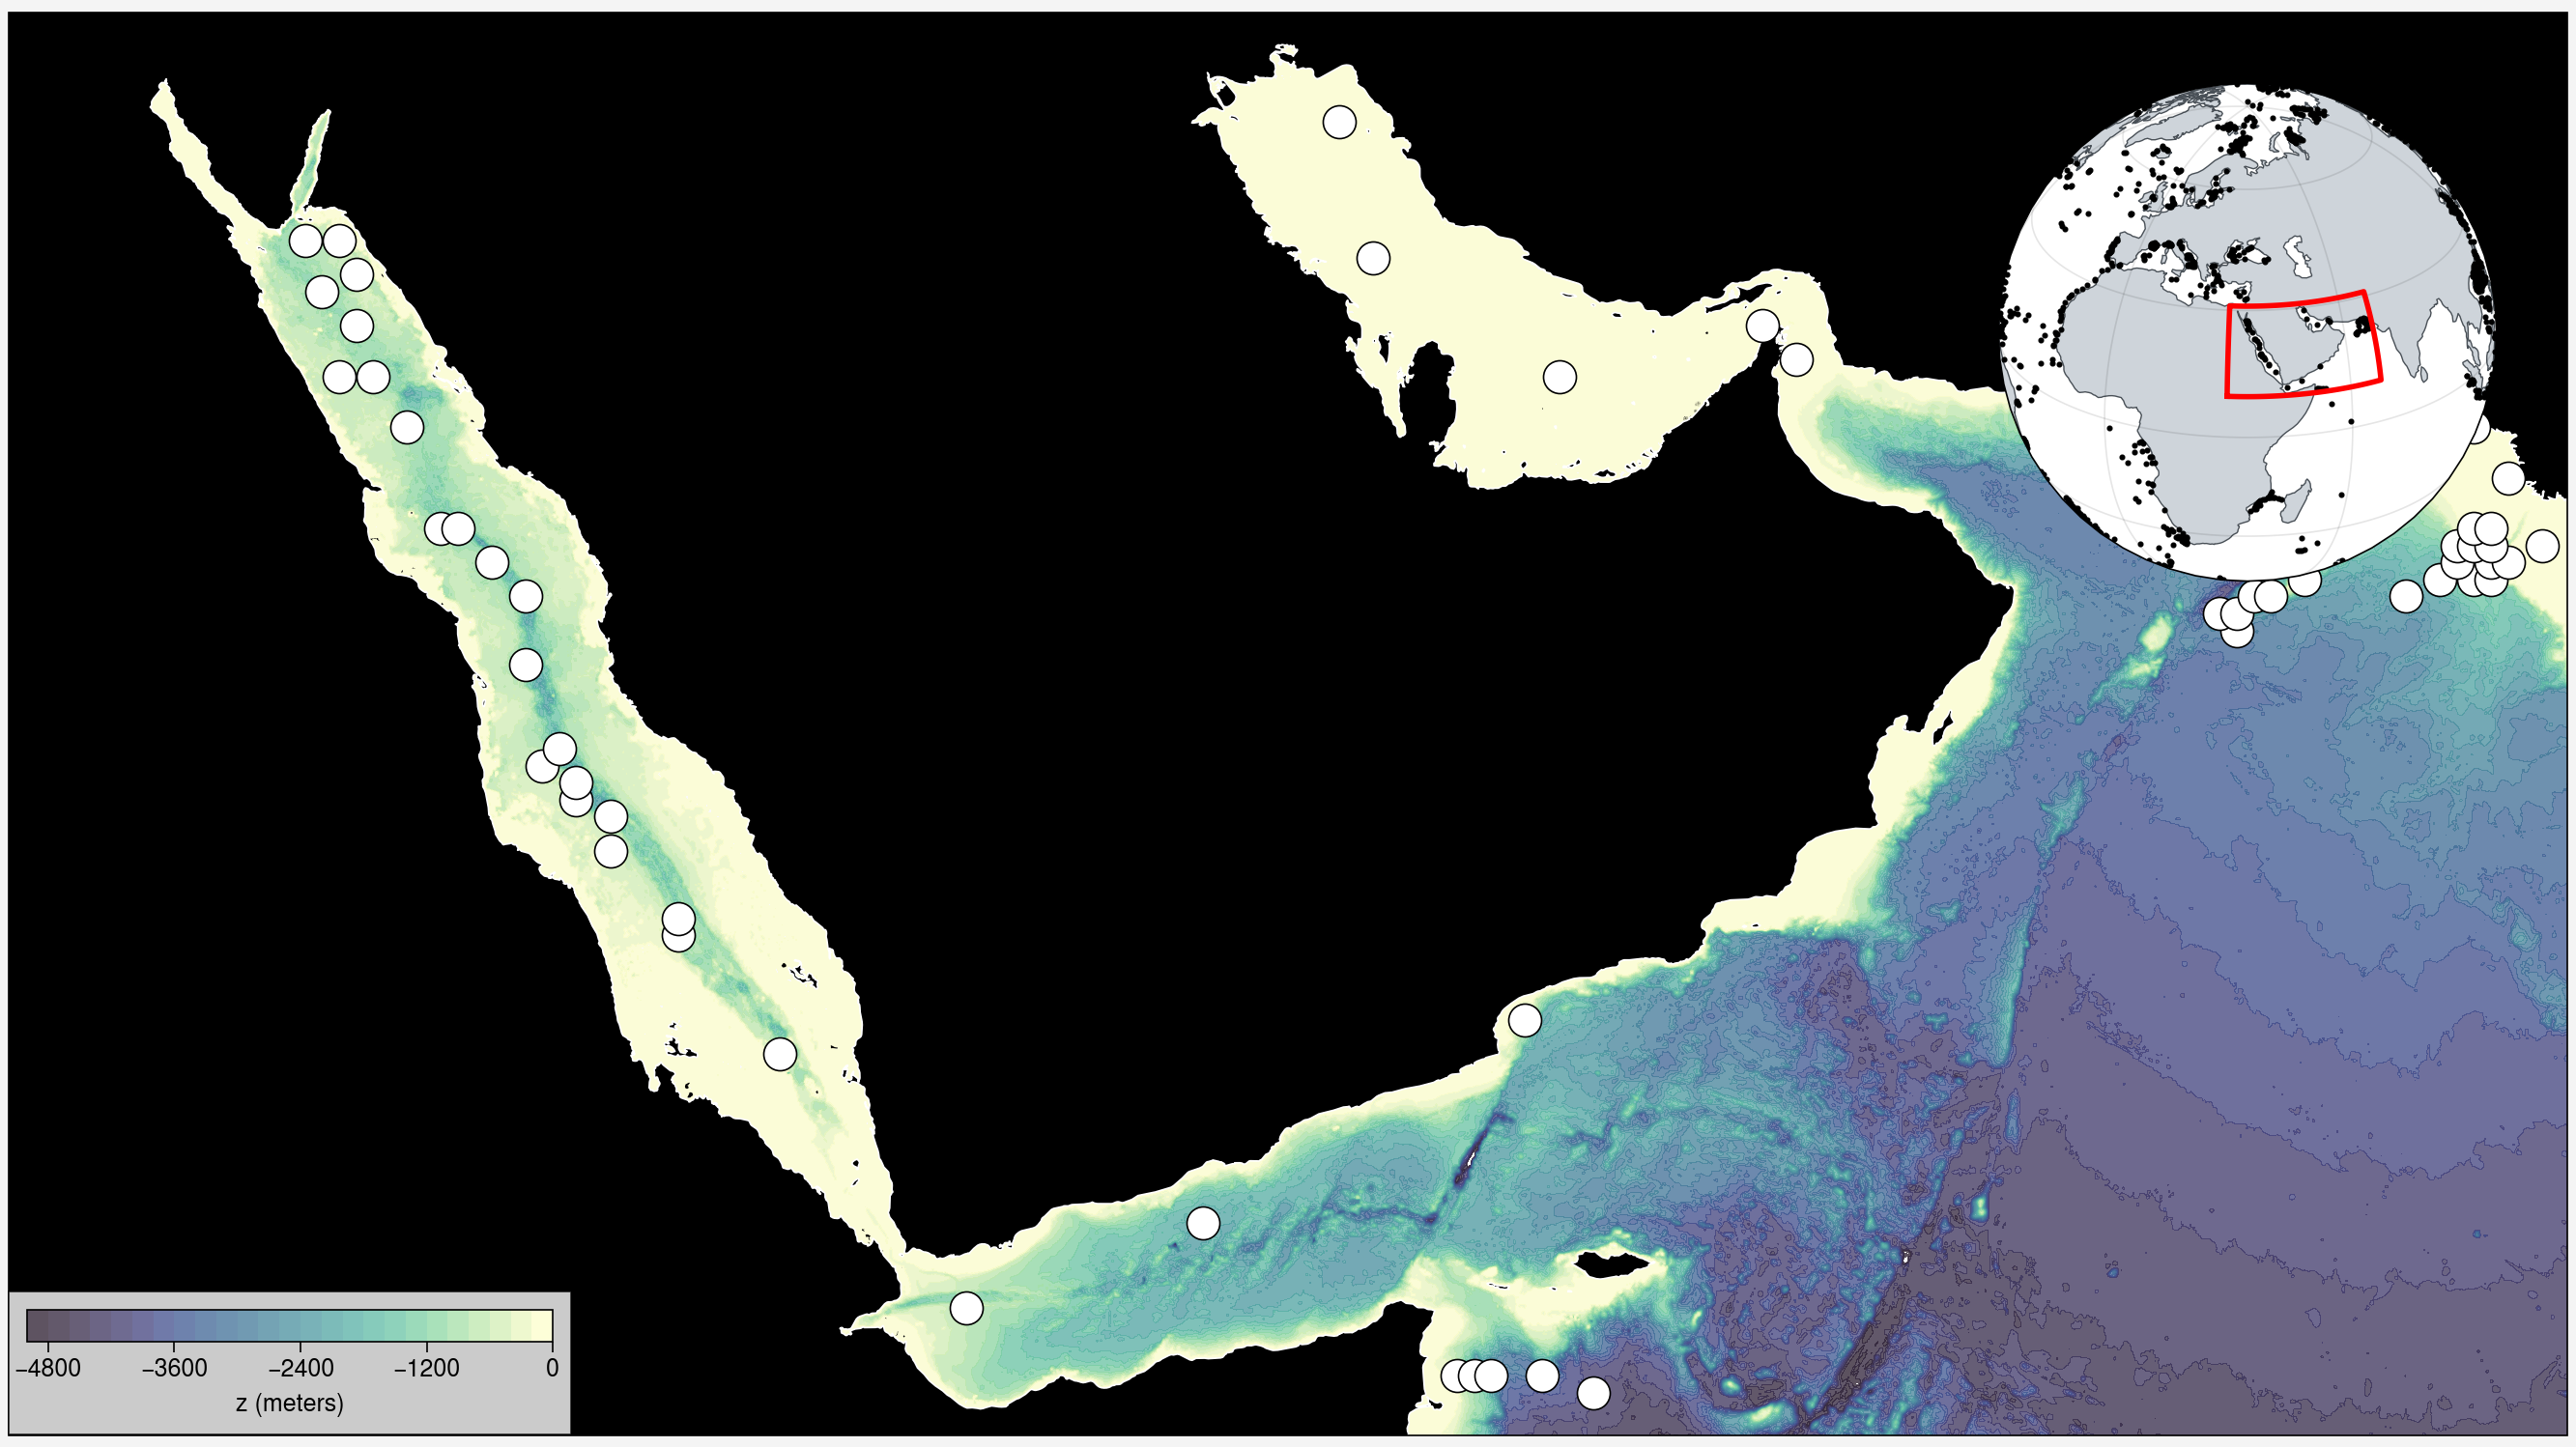

In [5]:
fig, axs = plot.subplots(proj='cyl',width=12,figsize=(13.33,7.49))
plot.rc.reso = 'hi'
lon_min, lon_max = 30.25, 68
lat_min, lat_max = 10, 31
gmt_bathy_da = pygmt.datasets.load_earth_relief(resolution="30s", region=[lon_min,lon_max,lat_min,lat_max], registration=None, data_source='igpp', use_srtm=False)

ax = axs[0,0]
ax.format(
    latlabels=False,
    lonlabels=False,
    lonlim=(lon_min,lon_max),
    latlim=(lat_min,lat_max),
    coast=True,coastzorder=2,coastcolor='w',
    land=True,landzorder=1,landcolor='k',
    alpha=0.5,
    grid=False
)

plot_data = gmt_bathy_da.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max))
plot_lat = gmt_bathy_da.lat
plot_lon = gmt_bathy_da.lon

m = ax.contourf(plot_lon,plot_lat,plot_data,cmap='deep_r',levels=np.arange(-5000,10,200),alpha=0.75,zorder=0)
# ax.contour(plot_lon,plot_lat,plot_data,linecolor='black',linewidth=0.25,levels=np.arange(-5000,5100,200))
ax.colorbar(m,loc='ll',shrink=20)

plot_x = coretop_df['lon']
plot_y = coretop_df['lat']

ax.scatter(plot_x,plot_y,c='w',mec='k',m='o',s=150,zorder=3)


##########################
# Create an inset axis overlapping on the top right corner of axs[0]
plot.rc.reso = 'lo'
ax_inset = axs[0].inset_axes([0.7, 0.6, 0.35, 0.35],
                             proj='ortho',proj_kw={'lon_0':35,'lat_0':25})
ax_inset.format(land=True, 
                landcolor='gray4',landzorder=0,
                grid=True,
                coast=True, coastcolor='gray7',coastlinewidth=0.5,coastzorder=1,
                )


# Your modified code section:
# Replace this part:
# rect = Rectangle((lon_min,lat_min), lon_max - lon_min, lat_max - lat_min, edgecolor='red9',
#                  facecolor='none',transform=ccrs.PlateCarree())
# ax_inset.add_patch(rect)

# With this:
boundary_lons, boundary_lats = create_latlon_boundary(lon_min, lon_max, lat_min, lat_max, n_points=50)

# Method 1: Using plot (recommended - simple and effective)
ax_inset.plot(boundary_lons, boundary_lats, 'red', linewidth=2, 
              transform=ccrs.PlateCarree(), zorder=10)
ax_inset.scatter(coretop_df['lon'],coretop_df['lat'],m='.',c='k',s=10,zorder=2)




fpath = f'/home/micromamba/app/figures/IMOG2025'
fname = 'map01_bathymetry_coretop'
fig.savefig(
    os.path.join(fpath,fname+'.png'),
    box_inches='tight',embed_fonts=True,dpi=600
)

In [6]:
fpath = f'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature'
fname = 'woa23_decav91C0_t00_04.nc'

T_da = xr.open_dataset(os.path.join(fpath, fname), decode_times=False)
woas23_temp = T_da.t_an.squeeze('time')
woas23_temp

<xarray.DataArray 't_an' (depth: 102, lat: 720, lon: 1440)>
[105753600 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
    time     float32 1.878e+03
Attributes:
    standard_name:  sea_water_temperature
    long_name:      Objectively analyzed mean fields for sea_water_temperatur...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          degrees_celsius

In [7]:
fpath = f'{local_onedrive_path}/Postdoc/WOA23/decav91C0/nitrate'
fname = 'woa23_all_n00_01.nc'

no3_da = xr.open_dataset(os.path.join(fpath, fname), decode_times=False)
woas23_no3 = no3_da.n_an.squeeze('time')
woas23_no3

<xarray.DataArray 'n_an' (depth: 102, lat: 180, lon: 360)>
[6609600 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
    time     float32 3.894e+03
Attributes:
    standard_name:  moles_of_nitrate_per_unit_mass_in_sea_water
    long_name:      Objectively analyzed mean fields for moles_of_nitrate_per...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          micromoles_per_kilogram

/opt/conda/envs/texas-env/lib/python3.10/site-packages/matplotlib_inline/backend_inline.py:27: ProplotWarning: Got conflicting or duplicate keyword args: {'figwidth': 13.33, 'width': 12}. Using the first one.
  return new_figure_manager_given_figure(num, FigureClass(*args, **kwargs))
/opt/conda/envs/texas-env/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/opt/conda/envs/texas-env/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/opt/conda/envs/texas-env/lib/python3.10/site-packages/proplot/figure.py:469: MatplotlibDeprecationWarning: print_figure() got unexpected keyword argument "box_inches" which is no longer supporte

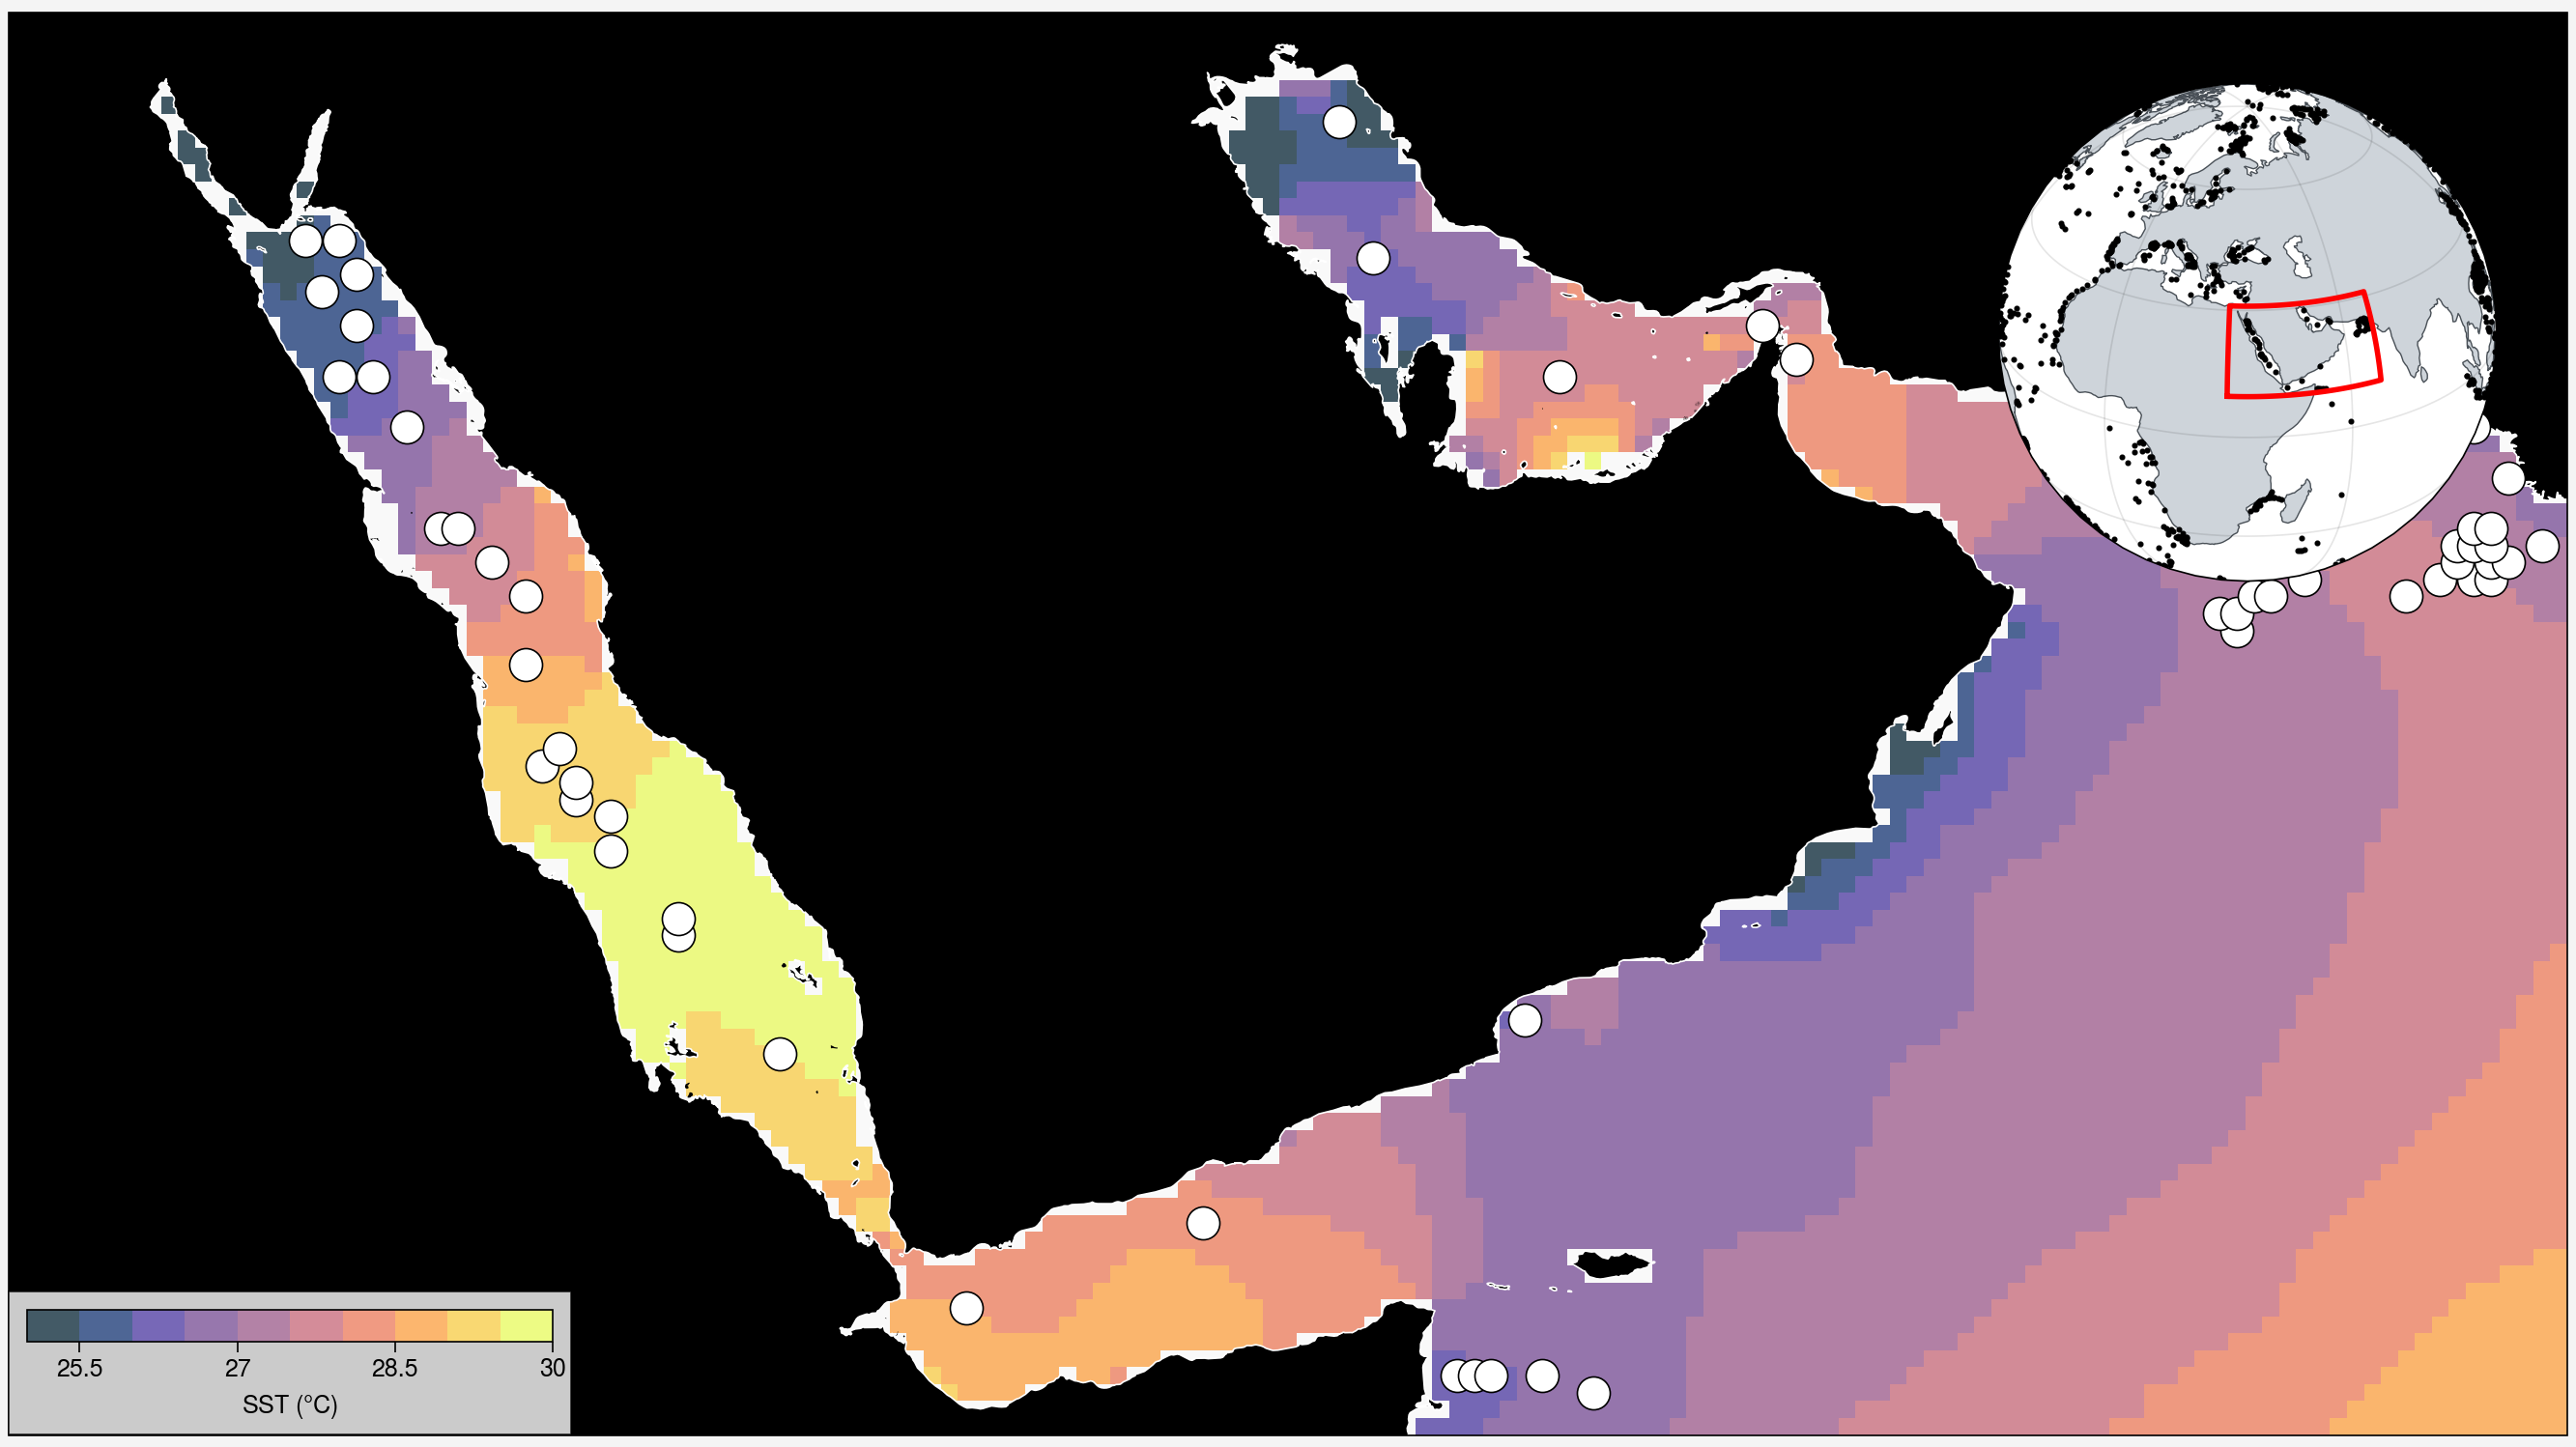

In [15]:
fig, axs = plot.subplots(proj='cyl',width=12,figsize=(13.33,7.49))
plot.rc.reso = 'hi'
lon_min, lon_max = 30.25, 68
lat_min, lat_max = 10, 31
gmt_bathy_da = pygmt.datasets.load_earth_relief(resolution="30s", region=[lon_min,lon_max,lat_min,lat_max], registration=None, data_source='igpp', use_srtm=False)

ax = axs[0,0]
ax.format(
    latlabels=False,
    lonlabels=False,
    lonlim=(lon_min,lon_max),
    latlim=(lat_min,lat_max),
    coast=True,coastzorder=2,coastcolor='w',
    land=True,landzorder=1,landcolor='k',
    alpha=0.5,
    grid=False
)

plot_data = woas23_temp.isel(depth=0)
plot_lat = woas23_temp.lat
plot_lon = woas23_temp.lon

m = ax.pcolormesh(plot_lon,plot_lat,plot_data,cmap='thermal',levels=np.arange(25,30.5,0.5),alpha=0.75,zorder=0)
# ax.contour(plot_lon,plot_lat,plot_data,linecolor='black',linewidth=0.25,levels=np.arange(-5000,5100,200))
ax.colorbar(m,loc='ll',shrink=20,title=r'SST ($\degree$C)')

#####
# plot_x = coretop_df['lon']
# plot_y = coretop_df['lat']
# ax.scatter(plot_x,plot_y,c='w',mec='k',m='o',s=150,zorder=3)

grouped = coretop_df.groupby('region_ID')
for name, group in grouped:
    plot_x = group['lon']
    plot_y = group['lat']
    ax.scatter(plot_x,plot_y,
            #    c='pink9' if name==31 else 'w',
            c='w',
            mec='k',
            m='o',s=150,zorder=3)


##########################
# Create an inset axis overlapping on the top right corner of axs[0]
plot.rc.reso = 'lo'
ax_inset = axs[0].inset_axes([0.7, 0.6, 0.35, 0.35],
                             proj='ortho',proj_kw={'lon_0':35,'lat_0':25})
ax_inset.format(land=True, 
                landcolor='gray4',landzorder=0,
                grid=True,
                coast=True, coastcolor='gray7',coastlinewidth=0.5,coastzorder=1,
                )


# Your modified code section:
# Replace this part:
# rect = Rectangle((lon_min,lat_min), lon_max - lon_min, lat_max - lat_min, edgecolor='red9',
#                  facecolor='none',transform=ccrs.PlateCarree())
# ax_inset.add_patch(rect)

# With this:
boundary_lons, boundary_lats = create_latlon_boundary(lon_min, lon_max, lat_min, lat_max, n_points=50)

# Method 1: Using plot (recommended - simple and effective)
ax_inset.plot(boundary_lons, boundary_lats, 'red', linewidth=2, 
              transform=ccrs.PlateCarree(), zorder=10)
ax_inset.scatter(coretop_df['lon'],coretop_df['lat'],m='.',c='k',s=10,zorder=2)




fpath = f'/home/micromamba/app/figures/IMOG2025'
fname = 'map01_sst_coretop_reasea'
fig.savefig(
    os.path.join(fpath,fname+'.png'),
    box_inches='tight',embed_fonts=True,dpi=600
)

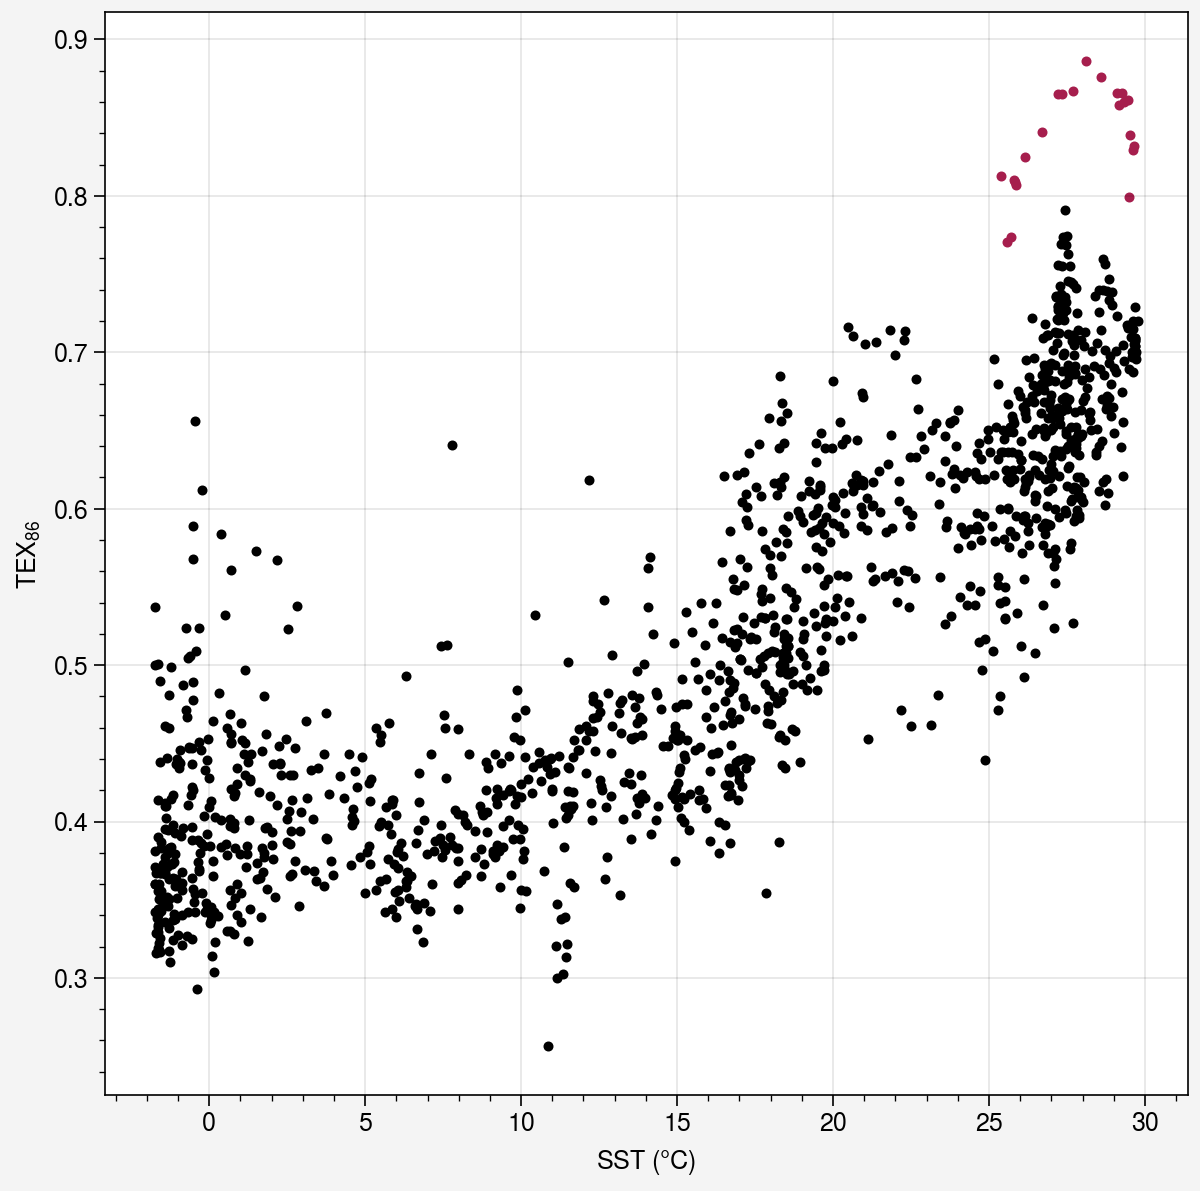

In [13]:
fig, axs = plot.subplots(width=6)

lon_min, lon_max = 30.25, 68
lat_min, lat_max = 10, 31

grouped = coretop_df.groupby('region_ID')
ax = axs[0]

for name, group in grouped:
    plot_x = group['sst']
    plot_y = group['tex_median']
    ax.scatter(
        plot_x,plot_y,
        m = '.',
        c = 'pink9' if name==31 else 'k'
    )
    
ax.format(
    xlabel=r'SST ($\degree$C)',
    ylabel=r'TEX$_{86}$',
)
ax.set_facecolor('white') 
fpath = f'/home/micromamba/app/figures/IMOG2025'
fname = 'SST-TEX_inset.png'
fig.savefig(os.path.join(fpath,fname), 
            transparent=True, 
            bbox_inches='tight')

In [17]:
woas23_no3

<xarray.DataArray 'n_an' (depth: 102, lat: 180, lon: 360)>
[6609600 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
    time     float32 3.894e+03
Attributes:
    standard_name:  moles_of_nitrate_per_unit_mass_in_sea_water
    long_name:      Objectively analyzed mean fields for moles_of_nitrate_per...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          micromoles_per_kilogram

In [18]:
fig, axs = plot.subplots(proj='cyl',width=12,figsize=(13.33,7.49))
plot.rc.reso = 'hi'
lon_min, lon_max = 30.25, 68
lat_min, lat_max = 10, 31
gmt_bathy_da = pygmt.datasets.load_earth_relief(resolution="30s", region=[lon_min,lon_max,lat_min,lat_max], registration=None, data_source='igpp', use_srtm=False)

ax = axs[0,0]
ax.format(
    latlabels=False,
    lonlabels=False,
    lonlim=(lon_min,lon_max),
    latlim=(lat_min,lat_max),
    coast=True,coastzorder=2,coastcolor='w',
    land=True,landzorder=1,landcolor='k',
    alpha=0.5,
    grid=False
)

plot_data = np.log10(woas23_no3.isel(depth=0))
plot_lat = woas23_no3.lat
plot_lon = woas23_no3.lon

m = ax.pcolormesh(plot_lon,plot_lat,plot_data,cmap='magma',
                #   levels=[0.001,0.01,0.1,0,1,10],
                  alpha=0.75,zorder=0)
# ax.contour(plot_lon,plot_lat,plot_data,linecolor='black',linewidth=0.25,levels=np.arange(-5000,5100,200))
ax.colorbar(m,loc='ll',shrink=20,title=r'Nitrate ($\micro$mol/kg)')

#####
# plot_x = coretop_df['lon']
# plot_y = coretop_df['lat']
# ax.scatter(plot_x,plot_y,c='w',mec='k',m='o',s=150,zorder=3)

grouped = coretop_df.groupby('region_ID')
for name, group in grouped:
    plot_x = group['lon']
    plot_y = group['lat']
    ax.scatter(plot_x,plot_y,
            #    c='pink9' if name==31 else 'w',
            c='w',
            mec='k',
            m='o',s=150,zorder=3)


##########################
# Create an inset axis overlapping on the top right corner of axs[0]
plot.rc.reso = 'lo'
ax_inset = axs[0].inset_axes([0.7, 0.6, 0.35, 0.35],
                             proj='ortho',proj_kw={'lon_0':35,'lat_0':25})
ax_inset.format(land=True, 
                landcolor='gray4',landzorder=0,
                grid=True,
                coast=True, coastcolor='gray7',coastlinewidth=0.5,coastzorder=1,
                )


# Your modified code section:
# Replace this part:
# rect = Rectangle((lon_min,lat_min), lon_max - lon_min, lat_max - lat_min, edgecolor='red9',
#                  facecolor='none',transform=ccrs.PlateCarree())
# ax_inset.add_patch(rect)

# With this:
boundary_lons, boundary_lats = create_latlon_boundary(lon_min, lon_max, lat_min, lat_max, n_points=50)

# Method 1: Using plot (recommended - simple and effective)
ax_inset.plot(boundary_lons, boundary_lats, 'red', linewidth=2, 
              transform=ccrs.PlateCarree(), zorder=10)
ax_inset.scatter(coretop_df['lon'],coretop_df['lat'],m='.',c='k',s=10,zorder=2)




fpath = f'/home/micromamba/app/figures/IMOG2025'
fname = 'map02_no3_coretop_reasea'
fig.savefig(
    os.path.join(fpath,fname+'.png'),
    box_inches='tight',embed_fonts=True,dpi=600
)

/opt/conda/envs/texas-env/lib/python3.10/site-packages/matplotlib_inline/backend_inline.py:27: ProplotWarning: Got conflicting or duplicate keyword args: {'figwidth': 13.33, 'width': 12}. Using the first one.
  return new_figure_manager_given_figure(num, FigureClass(*args, **kwargs))
/opt/conda/envs/texas-env/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/opt/conda/envs/texas-env/lib/python3.10/site-packages/xarray/core/computation.py:761: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/opt/conda/envs/texas-env/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "


ValueError: 
\micro
^
Unknown symbol: \micro, found '\'  (at char 0), (line:1, col:1)

ValueError: 
\micro
^
Unknown symbol: \micro, found '\'  (at char 0), (line:1, col:1)

Figure(nrows=1, ncols=1, figwidth=13.33, figheight=7.49)